# K-means Downgrade Prediction
Повторяет всю логику `segment overflows.ipynb`, заменяя RFM-сегменты кластерами K-means.

**Структура:**
1. Загрузка данных
2. Обучение K-means на Q1 2017 + ранжирование кластеров
3. Применение модели ко всем кварталам
4. Панель переходов + метка downgrade
5. Markov + Bayesian baseline
6. Бинарные классификаторы
7. Survival analysis
8. Business application (Early Warning System)
9. SHAP
10. Сравнение с RFM (Cohen's Kappa)

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.cluster import KMeans

# --- Константы ---
N_CLUSTERS   = 10
RANDOM_STATE = 42

# Веса для ранжирования кластеров
RANK_WEIGHTS = {
    'avg_order_value': 0.35,
    'margin':          0.30,
    'delivered_ratio': 0.22,
    'cancel_ratio':    0.13,   # инвертировано: меньше = лучше
}

os.makedirs('models', exist_ok=True)
print('Setup done. N_CLUSTERS =', N_CLUSTERS)

Setup done. N_CLUSTERS = 10


## 1. Загрузка данных

In [2]:
df = pd.read_csv('data/client_pivot_quarter.csv')
df['quarter'] = pd.PeriodIndex(df['quarter'], freq='Q')
print(df.shape)
print(df['quarter'].value_counts().sort_index())
df.head(2)

(368032, 37)
quarter
2017Q1    102786
2017Q2    102435
2017Q3    113587
2017Q4     49224
Freq: Q-DEC, Name: count, dtype: int64


,Телефон_new,quarter,total_orders,delivered_ratio,items,most_freq_order_size,cancel_ratio,return_ratio,revenue,margin,...,FAR EAST,NORTH,PRIVOLZIE,SIBERIA,SOUTHERN,URAL,delivery_pick point,delivery_курьерская,delivery_самовывоз,payment_безналичная
0,55575048-54555048485775,2017Q3,6,0.333333,224,4,0.666667,0.0,310425.0,14935.28,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,1.000000
1,55574953-48485556555475,2017Q2,9,1.000000,1140,20,0.111111,0.0,294810.0,22829.77,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.222222,0.0,0.777778


In [3]:
# Столбцы для K-means
HEAVY_TAIL = ['items', 'revenue', 'margin', 'avg_order_value', 'most_freq_order_size']
STANDARD_FEATS = ['delivered_ratio', 'cancel_ratio', 'return_ratio', 'recency_days']
BASE_COLS = ['total_orders', 'days_since_first_purchase']
CATEGORY_COLS = [
    'ДЕТСКОЕ ПИТАНИЕ', 'ЖЕНСКИЕ ШТУЧКИ', 'ИГРУШКИ',
    'КАНЦТОВАРЫ, КНИГИ, ДИСКИ', 'КОСМЕТИКА/ГИГИЕНА',
    'КРУПНОГАБАРИТНЫЙ ТОВАР', 'ОБУВЬ', 'ПОДГУЗНИКИ',
    'СОПУТСТВУЮЩИЕ ТОВАРЫ', 'ТЕКСТИЛЬ, ТРИКОТАЖ',
    'ТЕХНИКА И ТОВАРЫ ДЛЯ ДОМА', 'ТОВАРЫ ДЛЯ ЖИВОТНЫХ',
    'ТОВАРЫ ДЛЯ КОРМЛЕНИЯ',
]
REGION_COLS  = ['CENTRAL', 'FAR EAST', 'NORTH', 'PRIVOLZIE', 'SIBERIA', 'SOUTHERN', 'URAL']
DELIVERY_COLS = ['delivery_pick point', 'delivery_курьерская', 'delivery_самовывоз', 'payment_безналичная']
OTHER_COLS = BASE_COLS + CATEGORY_COLS + REGION_COLS + DELIVERY_COLS

KM_FEATURES = HEAVY_TAIL + STANDARD_FEATS + OTHER_COLS
print(f'K-means features: {len(KM_FEATURES)}')
print(KM_FEATURES)

K-means features: 35
['items', 'revenue', 'margin', 'avg_order_value', 'most_freq_order_size', 'delivered_ratio', 'cancel_ratio', 'return_ratio', 'recency_days', 'total_orders', 'days_since_first_purchase', 'ДЕТСКОЕ ПИТАНИЕ', 'ЖЕНСКИЕ ШТУЧКИ', 'ИГРУШКИ', 'КАНЦТОВАРЫ, КНИГИ, ДИСКИ', 'КОСМЕТИКА/ГИГИЕНА', 'КРУПНОГАБАРИТНЫЙ ТОВАР', 'ОБУВЬ', 'ПОДГУЗНИКИ', 'СОПУТСТВУЮЩИЕ ТОВАРЫ', 'ТЕКСТИЛЬ, ТРИКОТАЖ', 'ТЕХНИКА И ТОВАРЫ ДЛЯ ДОМА', 'ТОВАРЫ ДЛЯ ЖИВОТНЫХ', 'ТОВАРЫ ДЛЯ КОРМЛЕНИЯ', 'CENTRAL', 'FAR EAST', 'NORTH', 'PRIVOLZIE', 'SIBERIA', 'SOUTHERN', 'URAL', 'delivery_pick point', 'delivery_курьерская', 'delivery_самовывоз', 'payment_безналичная']


## 2. Обучение K-means на Q1 2017

In [4]:
df_q1 = df[df['quarter'] == '2017Q1'].copy()

# Сдвиг margin (чтобы всё > 0 для log1p)
margin_shift_km = float(-df_q1['margin'].min() + 1.0)
df_q1['margin'] = df_q1['margin'] + margin_shift_km

# log1p для heavy-tail
for col in HEAVY_TAIL:
    df_q1[col] = np.log1p(df_q1[col].clip(lower=0.0))

# Fit scalers на Q1
robust_sc = RobustScaler()
df_q1[HEAVY_TAIL] = robust_sc.fit_transform(df_q1[HEAVY_TAIL])

std_sc_feats = StandardScaler()
df_q1[STANDARD_FEATS] = std_sc_feats.fit_transform(df_q1[STANDARD_FEATS])

std_sc_other = StandardScaler()
df_q1[OTHER_COLS] = std_sc_other.fit_transform(df_q1[OTHER_COLS].fillna(0))

X_q1 = df_q1[KM_FEATURES].values

# Обучаем K-means
km = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
km.fit(X_q1)
print('K-means trained. Inertia:', round(km.inertia_, 1))

# Сохраняем
joblib.dump(km, 'models/kmeans_q1_2017.pkl')
joblib.dump({
    'margin_shift': margin_shift_km,
    'robust_sc':    robust_sc,
    'std_sc_feats': std_sc_feats,
    'std_sc_other': std_sc_other,
}, 'models/scalers_q1_2017.pkl')
print('Scalers saved.')

K-means trained. Inertia: 2525735.5
Scalers saved.


## 3. Применение K-means ко всем кварталам

In [5]:
def scale_quarter(df_q, margin_shift, robust_sc, std_sc_feats, std_sc_other):
    """Масштабирует данные квартала с помощью scalers, обученных на Q1."""
    d = df_q.copy()
    d['margin'] = (d['margin'] + margin_shift).clip(lower=0.0)
    for col in HEAVY_TAIL:
        d[col] = np.log1p(d[col].clip(lower=0.0))
    d[HEAVY_TAIL]    = robust_sc.transform(d[HEAVY_TAIL])
    d[STANDARD_FEATS] = std_sc_feats.transform(d[STANDARD_FEATS])
    d[OTHER_COLS]    = std_sc_other.transform(d[OTHER_COLS].fillna(0))
    return d

records = []
for q in sorted(df['quarter'].unique()):
    df_q   = df[df['quarter'] == q].copy()
    df_q_s = scale_quarter(df_q, margin_shift_km, robust_sc, std_sc_feats, std_sc_other)
    X_q    = df_q_s[KM_FEATURES].values
    cluster_ids = km.predict(X_q)
    tmp = df[df['quarter'] == q][['Телефон_new', 'quarter']].copy()
    tmp['cluster_id'] = cluster_ids
    records.append(tmp)

df_clustered = pd.concat(records, ignore_index=True)
print(df_clustered.shape)
print(df_clustered.groupby('quarter')['cluster_id'].value_counts().unstack().fillna(0).astype(int))

(368032, 3)
cluster_id      0      1    2      3     4      5      6     7      8     9
quarter                                                                    
2017Q1      23676  10647  474  11703  6253  11637  14351  6357  16517  1171
2017Q2      21624  10053  405  10118  6934  12446  13555  8393  17799  1108
2017Q3      24652  13400  334   2588  6152  13350  20223  9836  21573  1479
2017Q4      10764   7474   21    941  1733   4642  11085  2699   9113   752


## 4. Ранжирование кластеров по бизнес-метрикам (Q1 профили)

In [6]:
# Профили кластеров по исходным (нескалированным) данным Q1
df_q1_orig = df[df['quarter'] == '2017Q1'].copy()
df_q1_orig['cluster_id'] = km.labels_

cluster_profiles = df_q1_orig.groupby('cluster_id').agg(
    avg_order_value=('avg_order_value', 'median'),
    margin=('margin', 'median'),
    delivered_ratio=('delivered_ratio', 'mean'),
    cancel_ratio=('cancel_ratio', 'mean'),
    n_clients=('Телефон_new', 'count'),
).reset_index()

# Нормализация 0-1
for col in ['avg_order_value', 'margin', 'delivered_ratio']:
    mn, mx = cluster_profiles[col].min(), cluster_profiles[col].max()
    cluster_profiles[f'{col}_norm'] = (cluster_profiles[col] - mn) / (mx - mn + 1e-9)

# cancel_ratio: меньше = лучше → инвертируем
mn, mx = cluster_profiles['cancel_ratio'].min(), cluster_profiles['cancel_ratio'].max()
cluster_profiles['cancel_ratio_norm'] = 1 - (cluster_profiles['cancel_ratio'] - mn) / (mx - mn + 1e-9)

cluster_profiles['score'] = (
    RANK_WEIGHTS['avg_order_value'] * cluster_profiles['avg_order_value_norm'] +
    RANK_WEIGHTS['margin']          * cluster_profiles['margin_norm'] +
    RANK_WEIGHTS['delivered_ratio'] * cluster_profiles['delivered_ratio_norm'] +
    RANK_WEIGHTS['cancel_ratio']    * cluster_profiles['cancel_ratio_norm']
)

cluster_profiles = cluster_profiles.sort_values('score').reset_index(drop=True)
cluster_profiles['cluster_rank'] = range(len(cluster_profiles))  # 0 = худший, 9 = лучший

CLUSTER_RANK = dict(zip(cluster_profiles['cluster_id'], cluster_profiles['cluster_rank']))

print('Cluster rank mapping (id → rank):', CLUSTER_RANK)
print()
cluster_profiles[['cluster_id', 'cluster_rank', 'score', 'avg_order_value', 'margin',
                   'delivered_ratio', 'cancel_ratio', 'n_clients']].round(3)

Cluster rank mapping (id → rank): {7: 0, 2: 1, 3: 2, 9: 3, 6: 4, 0: 5, 8: 6, 1: 7, 5: 8, 4: 9}



,cluster_id,cluster_rank,score,avg_order_value,margin,delivered_ratio,cancel_ratio,n_clients
0,7,0,0.116,2017.50,486.400,0.486,0.120,6357
1,2,1,0.245,2125.75,415.420,0.904,0.189,474
2,3,2,0.249,1330.00,179.000,0.904,0.133,11703
3,9,3,0.325,1957.00,75.490,0.920,0.074,1171
4,6,4,0.330,3124.00,589.120,0.914,0.153,14351
5,0,5,0.357,1410.00,260.605,0.966,0.054,23676
6,8,6,0.359,1889.00,173.770,0.951,0.057,16517
7,1,7,0.398,2233.00,770.840,0.950,0.075,10647
8,5,8,0.448,2560.00,867.180,0.958,0.044,11637
9,4,9,0.955,10990.00,4242.000,0.929,0.075,6253


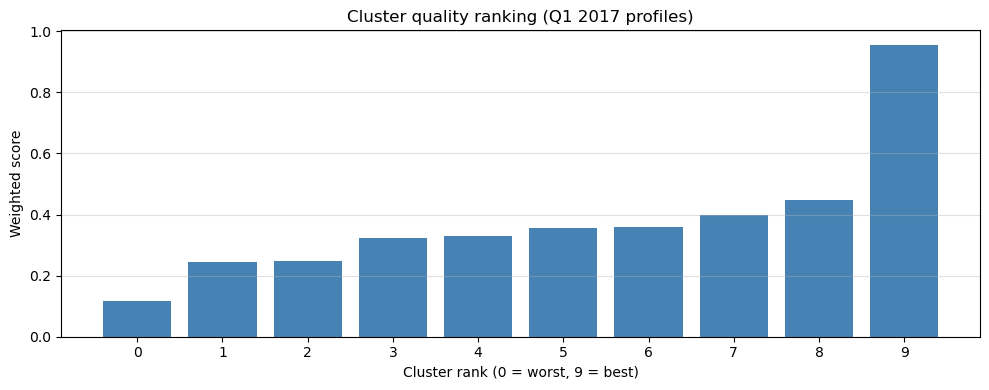

In [7]:
# Визуализация: score по кластерам
cp_plot = cluster_profiles.sort_values('cluster_rank')
plt.figure(figsize=(10, 4))
plt.bar(cp_plot['cluster_rank'], cp_plot['score'], color='steelblue')
plt.xlabel('Cluster rank (0 = worst, 9 = best)')
plt.ylabel('Weighted score')
plt.title('Cluster quality ranking (Q1 2017 profiles)')
plt.xticks(range(N_CLUSTERS))
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

## 5. Панель переходов и метка downgrade

In [8]:
# Добавляем cluster_rank
df_clustered['cluster_rank'] = df_clustered['cluster_id'].map(CLUSTER_RANK)

# Объединяем с исходным датафреймом (признаки клиентов)
df_km = df.merge(
    df_clustered[['Телефон_new', 'quarter', 'cluster_id', 'cluster_rank']],
    on=['Телефон_new', 'quarter'], how='left'
)

df_km = df_km.sort_values(['Телефон_new', 'quarter'])
df_km['cluster_id_next']   = df_km.groupby('Телефон_new')['cluster_id'].shift(-1)
df_km['cluster_rank_next'] = df_km.groupby('Телефон_new')['cluster_rank'].shift(-1)

transitions = df_km.dropna(subset=['cluster_id_next']).copy()
transitions['downgrade'] = (transitions['cluster_rank_next'] < transitions['cluster_rank']).astype(int)

print('Transitions shape:', transitions.shape)
print('\nDowngrade rate by quarter:')
print(transitions.groupby('quarter')['downgrade'].mean().round(3))

Transitions shape: (79089, 42)

Downgrade rate by quarter:
quarter
2017Q1    0.301
2017Q2    0.291
2017Q3    0.222
Freq: Q-DEC, Name: downgrade, dtype: float64


In [9]:
# Train: Q1→Q2, Q2→Q3  |  Test: Q3→Q4
quarters_sorted = sorted(transitions['quarter'].unique())
train_quarters  = quarters_sorted[:2]   # Q1, Q2
test_quarters   = [quarters_sorted[2]]  # Q3

train_km = transitions[transitions['quarter'].isin(train_quarters)].copy()
test_km  = transitions[transitions['quarter'].isin(test_quarters)].copy()

print(f'Train: {train_km.shape}  |  Test: {test_km.shape}')
print(f'Train downgrade rate: {train_km["downgrade"].mean():.3f}')
print(f'Test downgrade rate:  {test_km["downgrade"].mean():.3f}')

Train: (63845, 42)  |  Test: (15244, 42)
Train downgrade rate: 0.296
Test downgrade rate:  0.222


## 6. Markov матрица переходов + Bayesian baseline

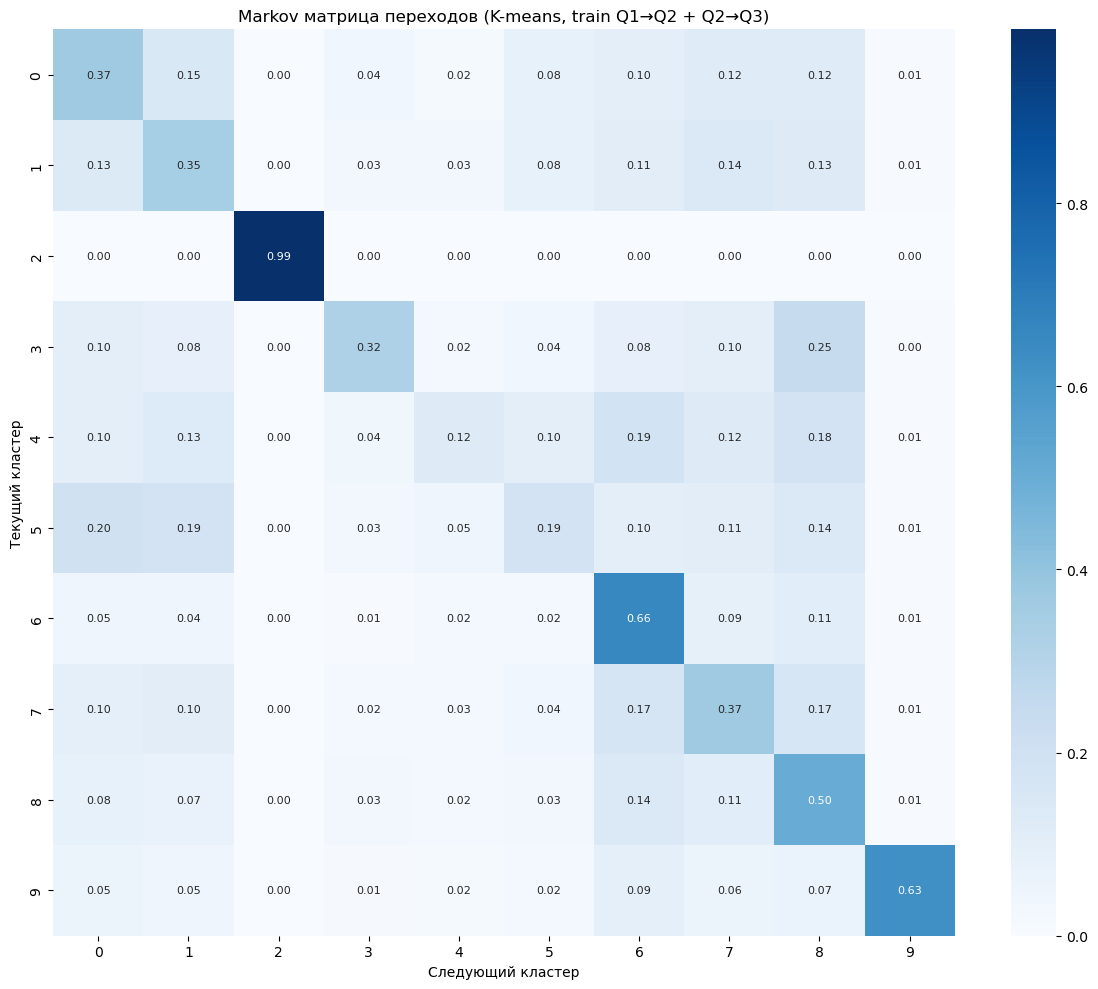

In [10]:
states = sorted(df_km['cluster_id'].dropna().unique().astype(int).tolist())

train_m = train_km.copy()
train_m['cluster_id']      = train_m['cluster_id'].astype(int)
train_m['cluster_id_next'] = train_m['cluster_id_next'].astype(int)

counts_km = pd.crosstab(train_m['cluster_id'], train_m['cluster_id_next'])
counts_km = counts_km.reindex(index=states, columns=states, fill_value=0)
P_km = counts_km.div(counts_km.sum(axis=1), axis=0).fillna(0)

plt.figure(figsize=(12, 10))
sns.heatmap(P_km, annot=True, cmap='Blues', fmt='.2f', annot_kws={'size': 8})
plt.title('Markov матрица переходов (K-means, train Q1→Q2 + Q2→Q3)')
plt.xlabel('Следующий кластер')
plt.ylabel('Текущий кластер')
plt.tight_layout()
plt.show()

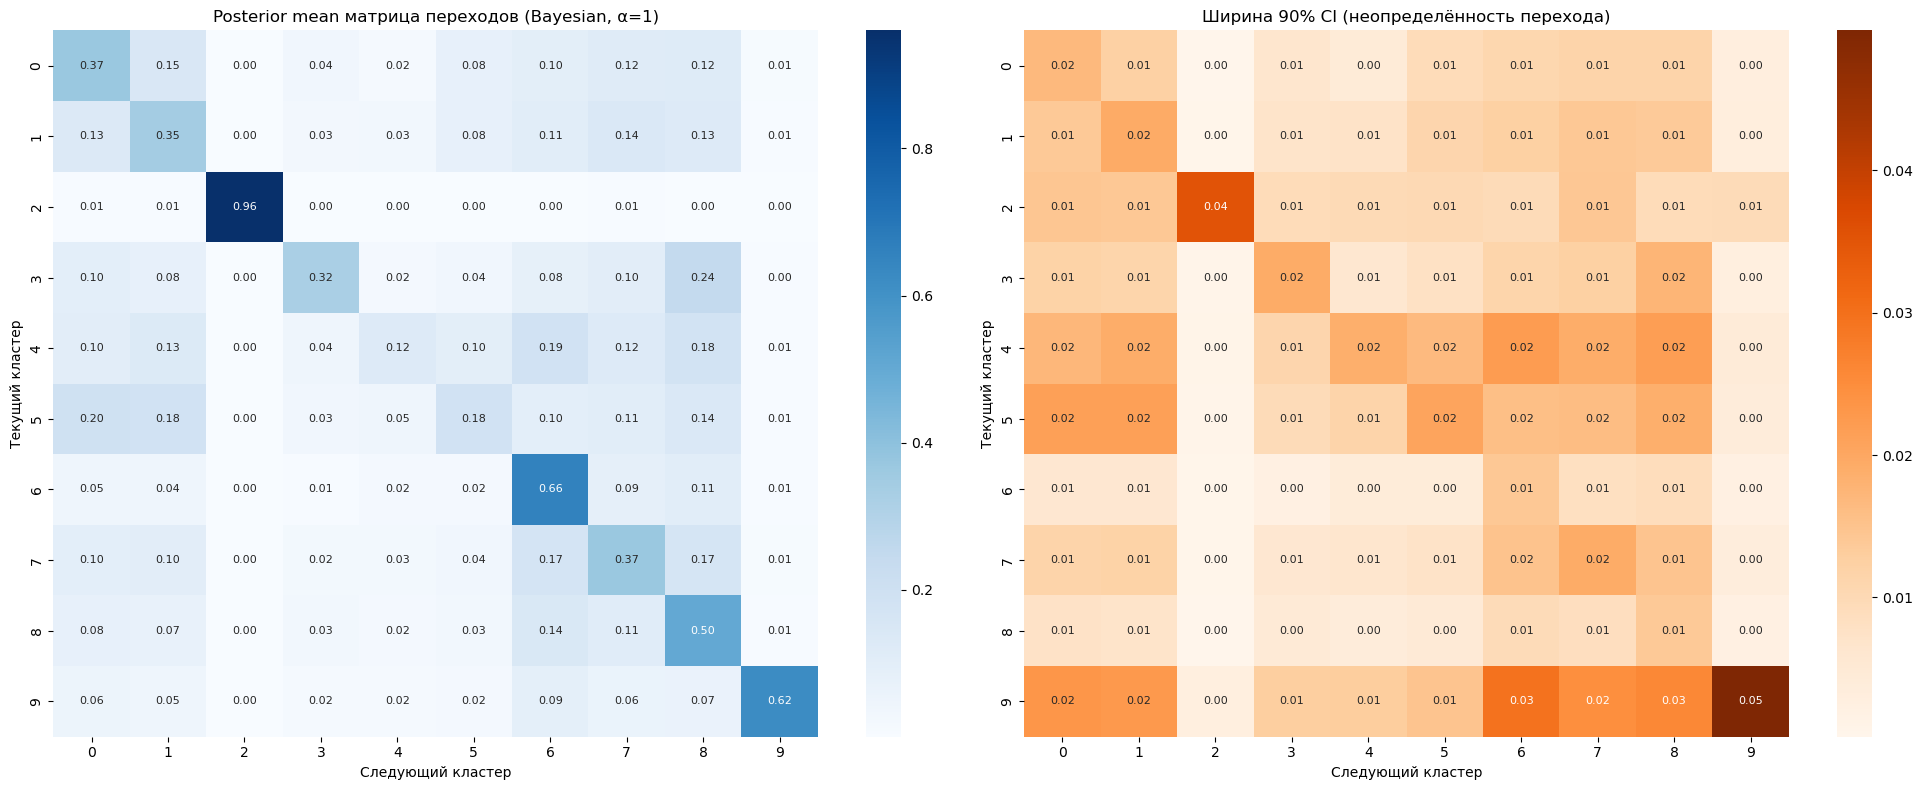

In [11]:
# Bayesian Dirichlet-Multinomial smoothing (α=1)
alpha_km = counts_km + 1

N_SAMPLES = 5000
posterior_km = {s: np.random.dirichlet(alpha_km.loc[s].values.astype(float), size=N_SAMPLES)
                for s in states}

P_bayes_km = pd.DataFrame(
    {s: alpha_km.loc[s].values / alpha_km.loc[s].values.sum() for s in states},
    index=states
).T

ci_low_km  = pd.DataFrame({s: np.percentile(posterior_km[s],  5, axis=0) for s in states}, index=states).T
ci_high_km = pd.DataFrame({s: np.percentile(posterior_km[s], 95, axis=0) for s in states}, index=states).T

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(P_bayes_km, annot=True, fmt='.2f', cmap='Blues',  ax=axes[0], annot_kws={'size': 8})
axes[0].set_title('Posterior mean матрица переходов (Bayesian, α=1)')
sns.heatmap(ci_high_km - ci_low_km, annot=True, fmt='.2f', cmap='Oranges', ax=axes[1], annot_kws={'size': 8})
axes[1].set_title('Ширина 90% CI (неопределённость перехода)')
for ax in axes:
    ax.set_xlabel('Следующий кластер')
    ax.set_ylabel('Текущий кластер')
plt.tight_layout()
plt.show()

In [12]:
# Оценка Markov baseline на тесте
from sklearn.metrics import accuracy_score, log_loss

test_m = test_km.copy()
test_m['cluster_id']      = test_m['cluster_id'].astype(int)
test_m['cluster_id_next'] = test_m['cluster_id_next'].astype(int)

labels_sorted = sorted(states)
proba_bayes = np.vstack(
    [P_bayes_km.loc[row['cluster_id'], labels_sorted].values for _, row in test_m.iterrows()]
)
y_pred_markov = [labels_sorted[i] for i in np.argmax(proba_bayes, axis=1)]

acc_markov  = accuracy_score(test_m['cluster_id_next'], y_pred_markov)
loss_markov = log_loss(test_m['cluster_id_next'], proba_bayes, labels=labels_sorted)

print(f'Markov Bayesian — Accuracy: {acc_markov:.4f}  |  Log-loss: {loss_markov:.4f}')

Markov Bayesian — Accuracy: 0.5350  |  Log-loss: 1.4322


## 7. Матрица признаков для бинарных классификаторов

In [13]:
# cluster_rank вместо OHE сегмента
BASE_FEATS_BIN = [
    'total_orders', 'delivered_ratio', 'items', 'most_freq_order_size',
    'cancel_ratio', 'return_ratio', 'revenue', 'margin', 'avg_order_value',
    'recency_days', 'days_since_first_purchase',
    'ДЕТСКОЕ ПИТАНИЕ', 'ЖЕНСКИЕ ШТУЧКИ', 'ИГРУШКИ',
    'КАНЦТОВАРЫ, КНИГИ, ДИСКИ', 'КОСМЕТИКА/ГИГИЕНА',
    'КРУПНОГАБАРИТНЫЙ ТОВАР', 'ОБУВЬ', 'ПОДГУЗНИКИ',
    'СОПУТСТВУЮЩИЕ ТОВАРЫ', 'ТЕКСТИЛЬ, ТРИКОТАЖ',
    'ТЕХНИКА И ТОВАРЫ ДЛЯ ДОМА', 'ТОВАРЫ ДЛЯ ЖИВОТНЫХ',
    'ТОВАРЫ ДЛЯ КОРМЛЕНИЯ',
    'CENTRAL', 'FAR EAST', 'NORTH', 'PRIVOLZIE',
    'SIBERIA', 'SOUTHERN', 'URAL',
    'delivery_pick point', 'delivery_курьерская',
    'delivery_самовывоз', 'payment_безналичная',
    'cluster_rank',
]

X_train_bin = train_km[BASE_FEATS_BIN].copy()
y_train_bin = train_km['downgrade'].copy()
X_test_bin  = test_km[BASE_FEATS_BIN].copy()
y_test_bin  = test_km['downgrade'].copy()

print('X_train_bin:', X_train_bin.shape, '| X_test_bin:', X_test_bin.shape)
print('Train downgrade rate:', y_train_bin.mean().round(3))
print('Test downgrade rate: ', y_test_bin.mean().round(3))

X_train_bin: (63845, 36) | X_test_bin: (15244, 36)
Train downgrade rate: 0.296
Test downgrade rate:  0.222


In [14]:
# Preprocessing — тот же пайплайн что в segment overflows.ipynb
HEAVY_BIN    = ['items', 'revenue', 'margin', 'avg_order_value', 'most_freq_order_size']
STANDARD_BIN = ['delivered_ratio', 'cancel_ratio', 'return_ratio', 'recency_days']

for col in set(HEAVY_BIN + STANDARD_BIN):
    X_train_bin[col] = X_train_bin[col].astype(float)
    X_test_bin[col]  = X_test_bin[col].astype(float)

# margin shift (fit only on train)
margin_shift_bin = float(-X_train_bin['margin'].min() + 1.0)
X_train_bin['margin'] = X_train_bin['margin'] + margin_shift_bin
X_test_bin['margin']  = (X_test_bin['margin'] + margin_shift_bin).clip(lower=0.0)

# log1p heavy tail
for col in HEAVY_BIN:
    X_train_bin[col] = np.log1p(X_train_bin[col].clip(lower=0.0))
    X_test_bin[col]  = np.log1p(X_test_bin[col].clip(lower=0.0))

# RobustScaler
robust_sc_bin = RobustScaler()
X_train_bin[HEAVY_BIN] = robust_sc_bin.fit_transform(X_train_bin[HEAVY_BIN])
X_test_bin[HEAVY_BIN]  = robust_sc_bin.transform(X_test_bin[HEAVY_BIN])

# StandardScaler
std_sc_bin = StandardScaler()
X_train_bin[STANDARD_BIN] = std_sc_bin.fit_transform(X_train_bin[STANDARD_BIN])
X_test_bin[STANDARD_BIN]  = std_sc_bin.transform(X_test_bin[STANDARD_BIN])

# LightGBM и XGBoost не поддерживают спецсимволы в именах колонок
import re
from collections import Counter

def sanitize_col(name):
    cleaned = re.sub(r'[^\w]+', '_', str(name)).strip('_')
    return cleaned or 'feature'

def make_unique_feature_names(columns):
    counts = {}
    unique_names = []
    for col in columns:
        base = sanitize_col(col)
        idx = counts.get(base, 0)
        new_name = base if idx == 0 else f'{base}_{idx}'
        counts[base] = idx + 1
        unique_names.append(new_name)
    return unique_names

original_cols = X_train_bin.columns.tolist()
sanitized_base = [sanitize_col(c) for c in original_cols]
sanitized_cols = make_unique_feature_names(original_cols)

# Важно: назначаем имена по позиции, а не через rename(columns=dict),
# потому что после неудачного предыдущего запуска в DataFrame уже могут быть дубликаты.
X_train_bin.columns = sanitized_cols
X_test_bin.columns  = sanitized_cols

resolved_dups = {
    base: [name for name in sanitized_cols if name == base or name.startswith(f'{base}_')]
    for base, cnt in Counter(sanitized_base).items() if cnt > 1
}
if resolved_dups:
    print('Resolved sanitized duplicates:', resolved_dups)

assert X_train_bin.columns.is_unique, 'X_train_bin still has duplicate feature names'
assert X_test_bin.columns.is_unique, 'X_test_bin still has duplicate feature names'

print('X_train_bin:', X_train_bin.shape, '| NaNs:', X_train_bin.isna().sum().sum())
print('X_test_bin: ', X_test_bin.shape,  '| NaNs:', X_test_bin.isna().sum().sum())
print('Columns sanitized:', X_train_bin.columns.tolist())

X_train_bin: (63845, 36) | NaNs: 0
X_test_bin:  (15244, 36) | NaNs: 0
Columns sanitized: ['total_orders', 'delivered_ratio', 'items', 'most_freq_order_size', 'cancel_ratio', 'return_ratio', 'revenue', 'margin', 'avg_order_value', 'recency_days', 'days_since_first_purchase', 'ДЕТСКОЕ_ПИТАНИЕ', 'ЖЕНСКИЕ_ШТУЧКИ', 'ИГРУШКИ', 'КАНЦТОВАРЫ_КНИГИ_ДИСКИ', 'КОСМЕТИКА_ГИГИЕНА', 'КРУПНОГАБАРИТНЫЙ_ТОВАР', 'ОБУВЬ', 'ПОДГУЗНИКИ', 'СОПУТСТВУЮЩИЕ_ТОВАРЫ', 'ТЕКСТИЛЬ_ТРИКОТАЖ', 'ТЕХНИКА_И_ТОВАРЫ_ДЛЯ_ДОМА', 'ТОВАРЫ_ДЛЯ_ЖИВОТНЫХ', 'ТОВАРЫ_ДЛЯ_КОРМЛЕНИЯ', 'CENTRAL', 'FAR_EAST', 'NORTH', 'PRIVOLZIE', 'SIBERIA', 'SOUTHERN', 'URAL', 'delivery_pick_point', 'delivery_курьерская', 'delivery_самовывоз', 'payment_безналичная', 'cluster_rank']


## 8. Бинарные классификаторы

In [15]:
# --- Logistic Regression ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

logreg_bin = LogisticRegression(max_iter=4000, class_weight='balanced', random_state=RANDOM_STATE)
logreg_bin.fit(X_train_bin, y_train_bin)

y_pred_lr  = logreg_bin.predict(X_test_bin)
y_prob_lr  = logreg_bin.predict_proba(X_test_bin)[:, 1]

print('Logistic Regression')
print(f'  Accuracy: {accuracy_score(y_test_bin, y_pred_lr):.4f}')
print(f'  F1:       {f1_score(y_test_bin, y_pred_lr):.4f}')
print(f'  ROC-AUC:  {roc_auc_score(y_test_bin, y_prob_lr):.4f}')
print(classification_report(y_test_bin, y_pred_lr, digits=3))

Logistic Regression
  Accuracy: 0.7446
  F1:       0.5941
  ROC-AUC:  0.8720
              precision    recall  f1-score   support

           0      0.942     0.716     0.814     11867
           1      0.458     0.844     0.594      3377

    accuracy                          0.745     15244
   macro avg      0.700     0.780     0.704     15244
weighted avg      0.835     0.745     0.765     15244



Optimal threshold LR: 0.6035
F1 (opt): 0.620  |  ROC-AUC: 0.872


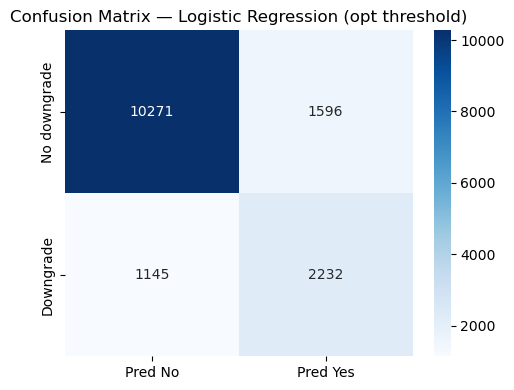

In [16]:
# Порог LR
from sklearn.metrics import precision_recall_curve

prec_lr, rec_lr, thr_lr = precision_recall_curve(y_test_bin, y_prob_lr)
f1_lr_arr = 2 * (prec_lr * rec_lr) / (prec_lr + rec_lr + 1e-8)
best_thr_lr = thr_lr[f1_lr_arr[:-1].argmax()]
y_pred_lr_opt = (y_prob_lr >= best_thr_lr).astype(int)

print(f'Optimal threshold LR: {best_thr_lr:.4f}')
print(f'F1 (opt): {f1_score(y_test_bin, y_pred_lr_opt):.3f}  |  ROC-AUC: {roc_auc_score(y_test_bin, y_prob_lr):.3f}')

cm = confusion_matrix(y_test_bin, y_pred_lr_opt)
cm_df = pd.DataFrame(cm, index=['No downgrade', 'Downgrade'], columns=['Pred No', 'Pred Yes'])
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix — Logistic Regression (opt threshold)')
plt.tight_layout()
plt.show()

In [17]:
# --- LightGBM ---
from lightgbm import LGBMClassifier

assert X_train_bin.columns.is_unique, f'Duplicate train columns: {X_train_bin.columns[X_train_bin.columns.duplicated()].tolist()}'
assert X_test_bin.columns.is_unique, f'Duplicate test columns: {X_test_bin.columns[X_test_bin.columns.duplicated()].tolist()}'

lgbm_bin = LGBMClassifier(
    objective='binary', n_estimators=300, learning_rate=0.05,
    num_leaves=15, max_depth=5, min_child_samples=50,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    class_weight='balanced', random_state=RANDOM_STATE,
    force_row_wise=True, verbose=-1
)
lgbm_bin.fit(X_train_bin, y_train_bin)

y_pred_lgbm  = lgbm_bin.predict(X_test_bin)
y_prob_lgbm  = lgbm_bin.predict_proba(X_test_bin)[:, 1]

print('LightGBM')
print(f'  Accuracy: {accuracy_score(y_test_bin, y_pred_lgbm):.4f}')
print(f'  F1:       {f1_score(y_test_bin, y_pred_lgbm):.4f}')
print(f'  ROC-AUC:  {roc_auc_score(y_test_bin, y_prob_lgbm):.4f}')
print(classification_report(y_test_bin, y_pred_lgbm, digits=3))

LightGBM
  Accuracy: 0.7591
  F1:       0.6099
  ROC-AUC:  0.8821
              precision    recall  f1-score   support

           0      0.945     0.733     0.826     11867
           1      0.475     0.850     0.610      3377

    accuracy                          0.759     15244
   macro avg      0.710     0.792     0.718     15244
weighted avg      0.841     0.759     0.778     15244



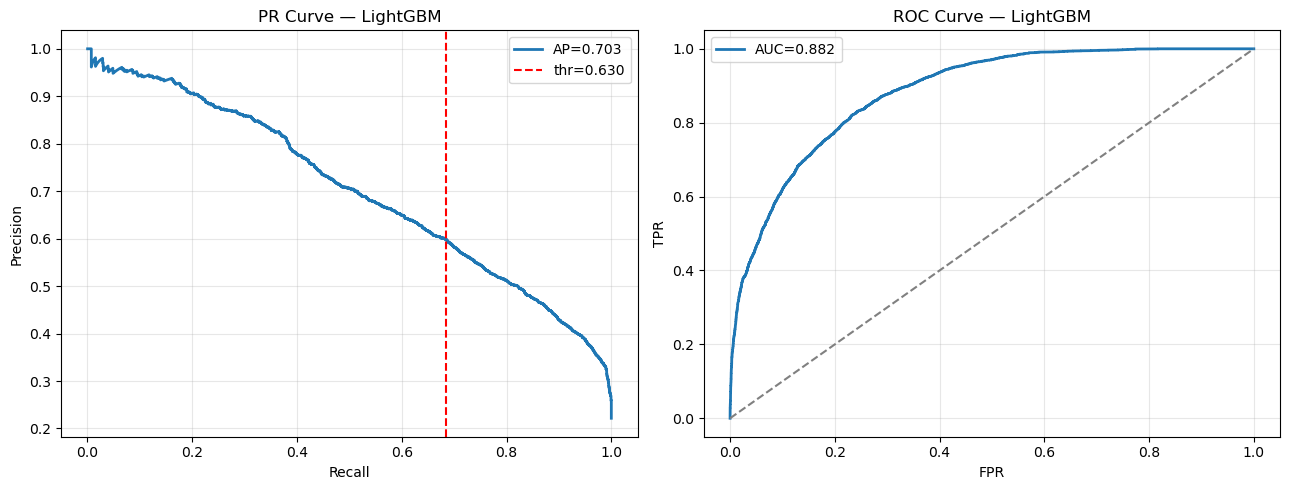

LightGBM opt thr=0.6304  F1=0.639  AUC=0.882


In [18]:
# Порог LightGBM + PR/ROC curves
from sklearn.metrics import precision_recall_curve, roc_curve, average_precision_score

prec_lgbm, rec_lgbm, thr_lgbm = precision_recall_curve(y_test_bin, y_prob_lgbm)
f1_lgbm_arr = 2 * (prec_lgbm * rec_lgbm) / (prec_lgbm + rec_lgbm + 1e-8)
best_thr_lgbm = thr_lgbm[f1_lgbm_arr[:-1].argmax()]
y_pred_lgbm_opt = (y_prob_lgbm >= best_thr_lgbm).astype(int)

fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test_bin, y_prob_lgbm)
ap_lgbm = average_precision_score(y_test_bin, y_prob_lgbm)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(rec_lgbm[:-1], prec_lgbm[:-1], lw=2, label=f'AP={ap_lgbm:.3f}')
best_idx = f1_lgbm_arr[:-1].argmax()
axes[0].axvline(rec_lgbm[best_idx], color='red', linestyle='--', label=f'thr={best_thr_lgbm:.3f}')
axes[0].set(xlabel='Recall', ylabel='Precision', title='PR Curve — LightGBM')
axes[0].legend(); axes[0].grid(alpha=0.3)

auc_lgbm = roc_auc_score(y_test_bin, y_prob_lgbm)
axes[1].plot(fpr_lgbm, tpr_lgbm, lw=2, label=f'AUC={auc_lgbm:.3f}')
axes[1].plot([0,1],[0,1], '--', color='gray')
axes[1].set(xlabel='FPR', ylabel='TPR', title='ROC Curve — LightGBM')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'LightGBM opt thr={best_thr_lgbm:.4f}  F1={f1_score(y_test_bin, y_pred_lgbm_opt):.3f}  AUC={auc_lgbm:.3f}')

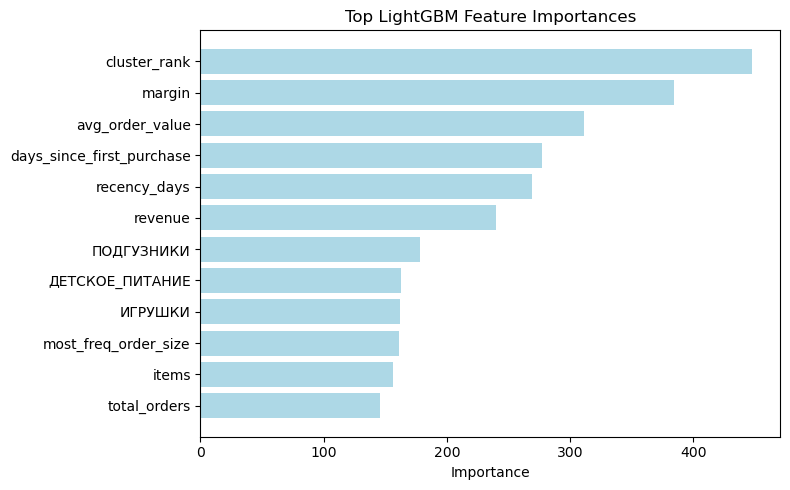

In [19]:
# LightGBM feature importance
fi_lgbm = pd.DataFrame({'feature': X_train_bin.columns,
                         'importance': lgbm_bin.feature_importances_}).sort_values('importance', ascending=False)
top12 = fi_lgbm.head(12).sort_values('importance')
plt.figure(figsize=(8, 5))
plt.barh(top12['feature'], top12['importance'], color='lightblue')
plt.xlabel('Importance')
plt.title('Top LightGBM Feature Importances')
plt.tight_layout()
plt.show()

In [20]:
# --- Random Forest ---
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=900, max_depth=10, min_samples_leaf=20,
    max_features=0.7, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_model.fit(X_train_bin, y_train_bin)

y_pred_rf  = rf_model.predict(X_test_bin)
y_proba_rf = rf_model.predict_proba(X_test_bin)[:, 1]

print('Random Forest')
print(f'  Accuracy: {accuracy_score(y_test_bin, y_pred_rf):.4f}')
print(f'  F1:       {f1_score(y_test_bin, y_pred_rf):.4f}')
print(f'  ROC-AUC:  {roc_auc_score(y_test_bin, y_proba_rf):.4f}')
print(classification_report(y_test_bin, y_pred_rf, digits=3))

Random Forest
  Accuracy: 0.7678
  F1:       0.6161
  ROC-AUC:  0.8821
              precision    recall  f1-score   support

           0      0.943     0.747     0.834     11867
           1      0.486     0.841     0.616      3377

    accuracy                          0.768     15244
   macro avg      0.714     0.794     0.725     15244
weighted avg      0.842     0.768     0.785     15244



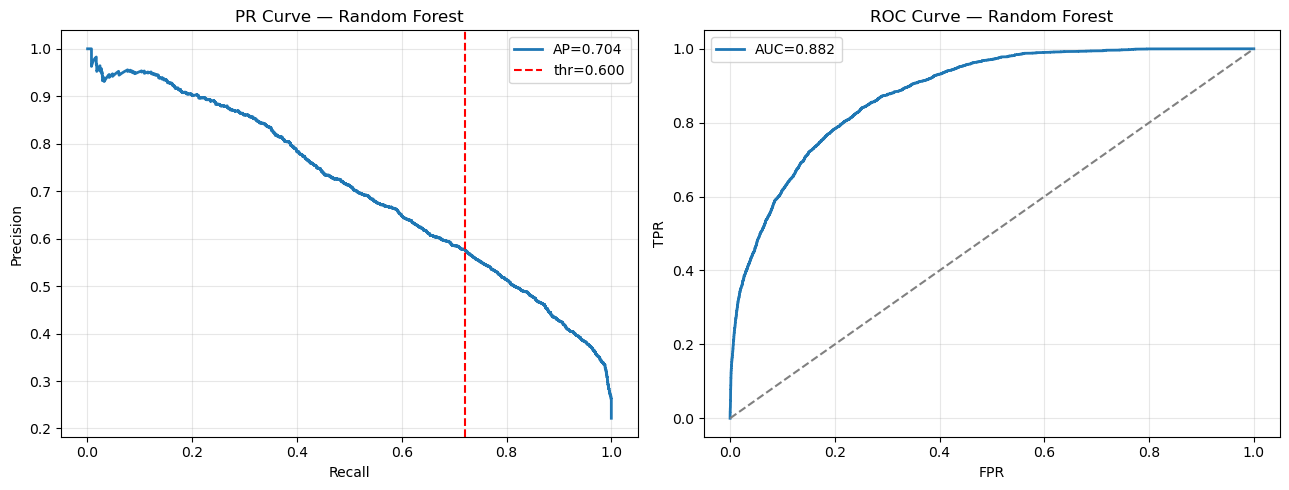

RF opt thr=0.5999  F1=0.641  AUC=0.882


In [21]:
# Порог RF + PR/ROC
prec_rf, rec_rf, thr_rf_arr = precision_recall_curve(y_test_bin, y_proba_rf)
f1_rf_arr = 2 * (prec_rf * rec_rf) / (prec_rf + rec_rf + 1e-8)
best_thr_rf = thr_rf_arr[f1_rf_arr[:-1].argmax()]
y_pred_rf_opt = (y_proba_rf >= best_thr_rf).astype(int)

fpr_rf, tpr_rf, _ = roc_curve(y_test_bin, y_proba_rf)
ap_rf  = average_precision_score(y_test_bin, y_proba_rf)
auc_rf = roc_auc_score(y_test_bin, y_proba_rf)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(rec_rf[:-1], prec_rf[:-1], lw=2, label=f'AP={ap_rf:.3f}')
axes[0].axvline(rec_rf[f1_rf_arr[:-1].argmax()], color='red', linestyle='--', label=f'thr={best_thr_rf:.3f}')
axes[0].set(xlabel='Recall', ylabel='Precision', title='PR Curve — Random Forest')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(fpr_rf, tpr_rf, lw=2, label=f'AUC={auc_rf:.3f}')
axes[1].plot([0,1],[0,1],'--',color='gray')
axes[1].set(xlabel='FPR', ylabel='TPR', title='ROC Curve — Random Forest')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'RF opt thr={best_thr_rf:.4f}  F1={f1_score(y_test_bin, y_pred_rf_opt):.3f}  AUC={auc_rf:.3f}')

In [22]:
# --- XGBoost ---
from xgboost import XGBClassifier

scale_pos_weight = (y_train_bin == 0).sum() / (y_train_bin == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective='binary:logistic', eval_metric='auc',
    scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE
)
xgb_model.fit(X_train_bin, y_train_bin)

y_pred_xgb  = xgb_model.predict(X_test_bin)
y_proba_xgb = xgb_model.predict_proba(X_test_bin)[:, 1]

print('XGBoost')
print(f'  Accuracy: {accuracy_score(y_test_bin, y_pred_xgb):.4f}')
print(f'  F1:       {f1_score(y_test_bin, y_pred_xgb):.4f}')
print(f'  ROC-AUC:  {roc_auc_score(y_test_bin, y_proba_xgb):.4f}')
print(classification_report(y_test_bin, y_pred_xgb, digits=3))

XGBoost
  Accuracy: 0.7652
  F1:       0.6145
  ROC-AUC:  0.8828
              precision    recall  f1-score   support

           0      0.944     0.743     0.831     11867
           1      0.483     0.845     0.615      3377

    accuracy                          0.765     15244
   macro avg      0.713     0.794     0.723     15244
weighted avg      0.842     0.765     0.783     15244



In [23]:
# Порог XGBoost
prec_xgb, rec_xgb, thr_xgb_arr = precision_recall_curve(y_test_bin, y_proba_xgb)
f1_xgb_arr = 2 * (prec_xgb * rec_xgb) / (prec_xgb + rec_xgb + 1e-8)
best_thr_xgb = thr_xgb_arr[f1_xgb_arr[:-1].argmax()]
y_pred_xgb_opt = (y_proba_xgb >= best_thr_xgb).astype(int)

auc_xgb = roc_auc_score(y_test_bin, y_proba_xgb)
print(f'XGBoost opt thr={best_thr_xgb:.4f}  F1={f1_score(y_test_bin, y_pred_xgb_opt):.3f}  AUC={auc_xgb:.3f}')

XGBoost opt thr=0.5886  F1=0.637  AUC=0.883


In [24]:
# --- SVM ---
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', C=1.0, gamma='scale',
                probability=True, class_weight='balanced', random_state=RANDOM_STATE))
])
svm_model.fit(X_train_bin, y_train_bin)

y_proba_svm = svm_model.predict_proba(X_test_bin)[:, 1]
y_pred_svm  = (y_proba_svm >= 0.5).astype(int)

print('SVM')
print(f'  Accuracy: {accuracy_score(y_test_bin, y_pred_svm):.4f}')
print(f'  F1:       {f1_score(y_test_bin, y_pred_svm):.4f}')
print(f'  ROC-AUC:  {roc_auc_score(y_test_bin, y_proba_svm):.4f}')

SVM
  Accuracy: 0.7945
  F1:       0.6076
  ROC-AUC:  0.8555


In [25]:
# Порог SVM
prec_svm, rec_svm, thr_svm_arr = precision_recall_curve(y_test_bin, y_proba_svm)
f1_svm_arr = 2 * (prec_svm * rec_svm) / (prec_svm + rec_svm + 1e-8)
best_thr_svm = thr_svm_arr[f1_svm_arr[:-1].argmax()]
y_pred_svm_opt = (y_proba_svm >= best_thr_svm).astype(int)

auc_svm = roc_auc_score(y_test_bin, y_proba_svm)
print(f'SVM opt thr={best_thr_svm:.4f}  F1={f1_score(y_test_bin, y_pred_svm_opt):.3f}  AUC={auc_svm:.3f}')

SVM opt thr=0.3987  F1=0.610  AUC=0.856


In [26]:
# --- MLP ---
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import RandomizedSearchCV

sample_weight_bin = compute_sample_weight(class_weight='balanced', y=y_train_bin)

mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPClassifier(
        early_stopping=True, validation_fraction=0.1,
        n_iter_no_change=15, random_state=RANDOM_STATE, max_iter=400
    ))
])

param_dist = {
    'model__hidden_layer_sizes': [(128, 64), (256, 128, 64), (128, 64, 32), (256, 128)],
    'model__alpha':              [1e-5, 1e-4, 1e-3, 1e-2],
    'model__learning_rate_init': [1e-4, 5e-4, 1e-3],
    'model__activation':         ['relu', 'tanh'],
    'model__batch_size':         [128, 256, 512],
}

search = RandomizedSearchCV(
    mlp_pipeline, param_dist, n_iter=20, cv=3,
    scoring='roc_auc', random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
search.fit(X_train_bin, y_train_bin, model__sample_weight=sample_weight_bin)

print(f'Best params: {search.best_params_}')
print(f'Best CV AUC: {search.best_score_:.4f}')

mlp_bin      = search.best_estimator_
y_proba_mlp  = mlp_bin.predict_proba(X_test_bin)[:, 1]

prec_mlp, rec_mlp, thr_mlp_arr = precision_recall_curve(y_test_bin, y_proba_mlp)
f1_mlp_arr = 2 * (prec_mlp * rec_mlp) / (prec_mlp + rec_mlp + 1e-8)
best_threshold = thr_mlp_arr[f1_mlp_arr[:-1].argmax()]
y_pred_mlp   = (y_proba_mlp >= best_threshold).astype(int)

auc_mlp = roc_auc_score(y_test_bin, y_proba_mlp)
print(f'MLP opt thr={best_threshold:.4f}  F1={f1_score(y_test_bin, y_pred_mlp):.3f}  AUC={auc_mlp:.3f}')

Best params: {'model__learning_rate_init': 0.0001, 'model__hidden_layer_sizes': (128, 64, 32), 'model__batch_size': 128, 'model__alpha': 0.001, 'model__activation': 'tanh'}
Best CV AUC: 0.8364
MLP opt thr=0.6040  F1=0.629  AUC=0.879


## 9. Итоговое сравнение моделей

In [27]:
from sklearn.metrics import recall_score, precision_score

models_info = [
    ('Logistic Regression', y_prob_lr,    y_pred_lr_opt,    best_thr_lr),
    ('LightGBM',            y_prob_lgbm,  y_pred_lgbm_opt,  best_thr_lgbm),
    ('Random Forest',       y_proba_rf,   y_pred_rf_opt,    best_thr_rf),
    ('XGBoost',             y_proba_xgb,  y_pred_xgb_opt,   best_thr_xgb),
    ('SVM',                 y_proba_svm,  y_pred_svm_opt,   best_thr_svm),
    ('MLP',                 y_proba_mlp,  y_pred_mlp,       best_threshold),
]

rows = []
for name, y_prob, y_pred, thr in models_info:
    rows.append({
        'Model':     name,
        'Threshold': round(thr, 3),
        'ROC AUC':   round(roc_auc_score(y_test_bin, y_prob), 3),
        'F1':        round(f1_score(y_test_bin, y_pred), 3),
        'Recall':    round(recall_score(y_test_bin, y_pred), 3),
        'Precision': round(precision_score(y_test_bin, y_pred), 3),
    })

comparison_km = pd.DataFrame(rows).set_index('Model').sort_values('F1', ascending=False)
print('=== K-means: все модели с оптимальным порогом ===')
comparison_km

=== K-means: все модели с оптимальным порогом ===


,Threshold,ROC AUC,F1,Recall,Precision
Model,,,,,
Random Forest,0.600,0.882,0.641,0.720,0.578
LightGBM,0.630,0.882,0.639,0.685,0.599
XGBoost,0.589,0.883,0.637,0.727,0.567
MLP,0.604,0.879,0.629,0.696,0.574
Logistic Regression,0.604,0.872,0.620,0.661,0.583
SVM,0.399,0.856,0.610,0.795,0.495


## 10. Сравнение K-means vs RFM

In [42]:
# Cohen's Kappa: насколько совпадают метки downgrade (K-means vs RFM)
# Для сравнения нужен df_rfm из segment overflows.ipynb
# Воспроизводим RFM-логику здесь

# --- RFM functions (копия из segment overflows.ipynb) ---
SEGMENT_RANK = {'Champions':5, 'Loyal':4, 'Promising':3, 'Regular':2, 'At Risk':1, 'Lost':0}

def score_asc(x, bins):
    if x <= bins[0]: return 5
    elif x <= bins[1]: return 4
    elif x <= bins[2]: return 3
    elif x <= bins[3]: return 2
    else: return 1

def score_desc(x, bins):
    if x <= bins[0]: return 1
    elif x <= bins[1]: return 2
    elif x <= bins[2]: return 3
    elif x <= bins[3]: return 4
    else: return 5

def score_frequency(x):
    if x <= 1: return 1
    elif x == 2: return 2
    elif x <= 4: return 3
    elif x <= 8: return 4
    else: return 5

def add_rfm_and_segment(df_in, bins_df=None):
    out = df_in.copy()
    out['recency_days'] = out['recency_days'].fillna(out['recency_days'].max())
    out['total_orders'] = out['total_orders'].fillna(0)
    out['margin']       = out['margin'].fillna(0)
    base = out if bins_df is None else bins_df
    q = [0.2, 0.4, 0.6, 0.8]
    r_bins = base['recency_days'].quantile(q).values
    m_bins = base['margin'].quantile(q).values
    out['R_score'] = out['recency_days'].apply(lambda x: score_asc(x, r_bins))
    out['F_score'] = out['total_orders'].apply(score_frequency)
    out['M_score'] = out['margin'].apply(lambda x: score_desc(x, m_bins))
    out['RFM_sum'] = out['R_score'] + out['F_score'] + out['M_score']
    conditions = [
        (out['R_score'] >= 4) & (out['F_score'] >= 3) & (out['M_score'] >= 3),
        (out['R_score'] >= 3) & (out['F_score'] >= 3),
        (out['R_score'] >= 4) & (out['F_score'] <= 2),
        (out['R_score'] <= 2) & ((out['F_score'] >= 3) | (out['M_score'] >= 3)),
        (out['R_score'] == 1) & (out['F_score'] <= 2) & (out['M_score'] <= 2),
    ]
    choices = ['Champions', 'Loyal', 'Promising', 'At Risk', 'Lost']
    out['segment'] = np.select(conditions, choices, default='Regular')
    return out

# Загружаем df ещё раз (без PeriodIndex чтобы не ломать bins_base)
df_raw = pd.read_csv('data/client_pivot_quarter.csv')
bins_base = df_raw[df_raw['quarter'] != '2017Q4'].copy()
df_rfm = add_rfm_and_segment(df_raw, bins_df=bins_base)
df_rfm['quarter'] = pd.PeriodIndex(df_rfm['quarter'], freq='Q')

# Строим RFM переходы
df_rfm = df_rfm.sort_values(['Телефон_new', 'quarter'])
df_rfm['segment_next'] = df_rfm.groupby('Телефон_new')['segment'].shift(-1)
df_rfm['rank_t']    = df_rfm['segment'].map(SEGMENT_RANK)
df_rfm['rank_next'] = df_rfm['segment_next'].map(SEGMENT_RANK)
df_rfm['downgrade_rfm'] = (df_rfm['rank_next'] < df_rfm['rank_t']).astype(int)

# Тест: Q3→Q4 (quarter == 2017Q3)
test_rfm = df_rfm[
    (df_rfm['quarter'] == '2017Q3') & df_rfm['segment_next'].notna()
].copy()

print('test_rfm:', test_rfm.shape)
print('RFM downgrade rate (test):', test_rfm['downgrade_rfm'].mean().round(3))

test_rfm: (15244, 46)
RFM downgrade rate (test): 0.847


In [43]:
from sklearn.metrics import cohen_kappa_score

# Совмещаем по Телефон_new на тест-периоде
compare_df = test_km[['Телефон_new', 'downgrade']].rename(columns={'downgrade': 'downgrade_km'}).merge(
    test_rfm[['Телефон_new', 'downgrade_rfm']],
    on='Телефон_new', how='inner'
)

print(f'Matched clients: {len(compare_df)}')
print(f'K-means downgrade rate:  {compare_df["downgrade_km"].mean():.3f}')
print(f'RFM downgrade rate:      {compare_df["downgrade_rfm"].mean():.3f}')

kappa = cohen_kappa_score(compare_df['downgrade_km'], compare_df['downgrade_rfm'])
print(f'\nCohen Kappa (K-means vs RFM downgrade labels): {kappa:.4f}')

ct = pd.crosstab(compare_df['downgrade_km'], compare_df['downgrade_rfm'],
                  rownames=['K-means'], colnames=['RFM'])
print('\nCross-tabulation:')
print(ct)

Matched clients: 15244
K-means downgrade rate:  0.222
RFM downgrade rate:      0.847

Cohen Kappa (K-means vs RFM downgrade labels): -0.0134

Cross-tabulation:
RFM         0      1
K-means             
0        1747  10120
1         588   2789


In [ ]:
# Сравнение ROC-AUC двух подходов
# Метрики RFM взяты из overflows RFM new.ipynb (Random Forest, opt threshold=0.308)

comparison_final = pd.DataFrame({
    'Метод':       ['K-means (этот ноутбук)', 'RFM (overflows RFM new.ipynb)'],
    'Best model':  ['LightGBM', 'Random Forest'],
    'ROC-AUC':     [round(auc_lgbm, 3), 0.758],
    'F1 (opt thr)': [round(f1_score(y_test_bin, y_pred_lgbm_opt), 3), 0.715],
    'Recall':      [round(recall_score(y_test_bin, y_pred_lgbm_opt), 3), 0.942],
    'Precision':   [round(precision_score(y_test_bin, y_pred_lgbm_opt), 3), 0.576],
    'Test size':   [len(y_test_bin), 15244],
    'Downgrade rate (test)': [round(y_test_bin.mean(), 3), 0.847],
})
print(comparison_final.to_string(index=False))

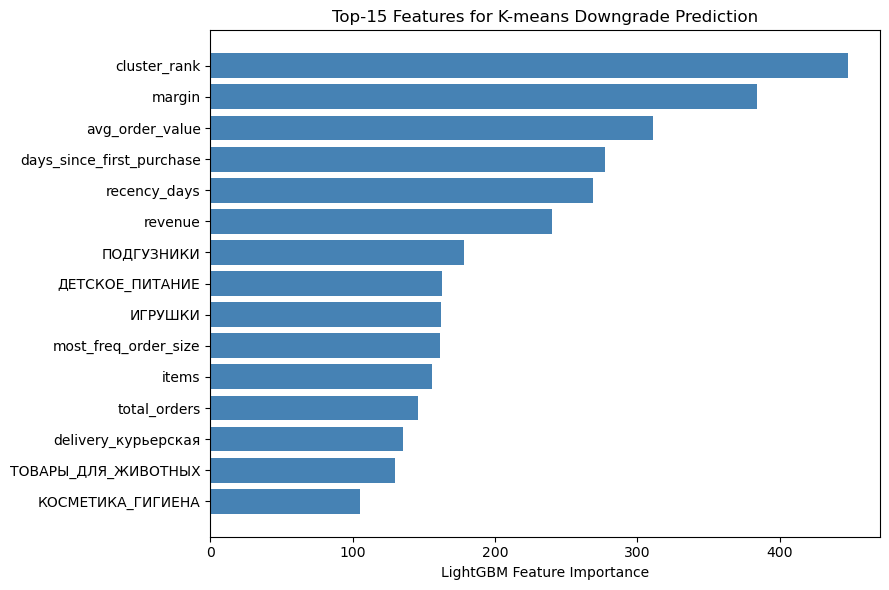


Позиция cluster_rank в feature importance:
         feature  importance
35  cluster_rank         448


In [45]:
# Feature importance: K-means vs RFM (топ-10)
# Для RFM берём из segment overflows fi_lgbm (нет здесь),
# поэтому показываем только K-means feature importance

fi_km_plot = fi_lgbm.head(15).sort_values('importance')

plt.figure(figsize=(9, 6))
plt.barh(fi_km_plot['feature'], fi_km_plot['importance'], color='steelblue')
plt.xlabel('LightGBM Feature Importance')
plt.title('Top-15 Features for K-means Downgrade Prediction')
plt.tight_layout()
plt.show()

print('\nПозиция cluster_rank в feature importance:')
print(fi_lgbm[fi_lgbm['feature'] == 'cluster_rank'])

In [46]:
print('=== ИТОГ ===')
print(f'Cohen Kappa (K-means vs RFM downgrade): {kappa:.4f}')
print()
print('Интерпретация:')
if kappa < 0.2:
    print('  Очень слабое согласие — K-means и RFM дают принципиально разные сигналы о downgrade.')
elif kappa < 0.4:
    print('  Слабое согласие — методы частично расходятся в определении at-risk клиентов.')
elif kappa < 0.6:
    print('  Умеренное согласие — методы похожи, но K-means улавливает дополнительные паттерны.')
elif kappa < 0.8:
    print('  Хорошее согласие — оба метода идентифицируют схожий набор at-risk клиентов.')
else:
    print('  Отличное согласие — K-means и RFM практически эквивалентны по сигналу о downgrade.')
print()
print(comparison_km.to_string())

=== ИТОГ ===
Cohen Kappa (K-means vs RFM downgrade): -0.0134

Интерпретация:
  Очень слабое согласие — K-means и RFM дают принципиально разные сигналы о downgrade.

                     Threshold  ROC AUC     F1  Recall  Precision
Model                                                            
Random Forest            0.600    0.882  0.641   0.720      0.578
LightGBM                 0.630    0.882  0.639   0.685      0.599
XGBoost                  0.589    0.883  0.637   0.727      0.567
MLP                      0.604    0.879  0.629   0.696      0.574
Logistic Regression      0.604    0.872  0.620   0.661      0.583
SVM                      0.399    0.856  0.610   0.795      0.495
